In [1]:
import torch

print("CUDA Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))
    print("GPU Count:", torch.cuda.device_count())
    print("Current Device:", torch.cuda.current_device())
else:
    print("No GPU Found")

CUDA Available: True
GPU Name: NVIDIA RTX PRO 6000 Blackwell Server Edition
GPU Count: 1
Current Device: 0


In [6]:
# ============================================================
# BTS-GAN + MONAI ULTRA PROFESSIONAL PIPELINE
# FIXED AUGMENTATION + STABLE GAN VERSION (WITH RESUME SYSTEM)
# NVIDIA RTX PRO 6000 BLACKWELL SERVER OPTIMIZED
# ============================================================

# ============================================================
# ÖNEMLİ DÜZELTMELER & YENİLİKLER
# ============================================================
# ✅ IMAGE + MASK augmentation senkronize edildi
# ✅ GAN stabilize edildi
# ✅ Discriminator zayıflatıldı
# ✅ BCEWithLogitsLoss düzeltildi
# ✅ Sigmoid Generator'dan kaldırıldı
# ✅ AMP autocast hatası çözüldü
# ✅ Dice Loss stabilize edildi
# ✅ Mixed Precision tamamen düzeltildi
# ✅ RTX PRO 6000 Blackwell için Maksimum Performans (IMG_SIZE=512, BATCH=8, WORKERS=8)
# ✅ TensorFloat-32 (TF32) Blackwell mimarisi için aktif
# ✅ Persistent workers aktif
# ✅ Non-blocking GPU transfer
# ✅ Gradient clipping eklendi
# ✅ NaN protection eklendi
# ✅ MONAI UNET kullanıldı
# ✅ Validation grafik sistemi geliştirildi
# ✅ Prediction visualization geliştirildi
# ✅ Cancer overlay sistemi geliştirildi
# ✅ AUTOMATIC RESUME SYSTEM + CHECKPOINTING ENTEGRE EDİLDİ
# ============================================================

# ============================================================
# 1. LIBRARIES
# ============================================================

!pip install -q monai

import os
import gc
import cv2
import json
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torchvision.transforms import functional as TF
from torch.utils.data import Dataset, DataLoader

from monai.networks.nets import UNet

from google.colab import drive

warnings.filterwarnings("ignore")

# ============================================================
# CUDA OPTIMIZATION (BLACKWELL TENSOR CORES FULL POWER)
# ============================================================

torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

# ============================================================
# 2. GOOGLE DRIVE
# ============================================================

print("\n🚀 Google Drive bağlanıyor...")
drive.mount('/content/drive', force_remount=False)

# ============================================================
# 3. PATHS
# ============================================================

IMAGE_PATH = '/content/drive/MyDrive/Colab Notebooks/BTS DATASET/dataset/seg/train/images'
MASK_PATH = '/content/drive/MyDrive/Colab Notebooks/BTS DATASET/dataset/seg/train/labels'
SAVE_DIR = '/content/drive/MyDrive/Colab Notebooks/BTS DATASET/BTS_GAN_MONAI_OUTPUT'

os.makedirs(SAVE_DIR, exist_ok=True)

PRED_DIR = os.path.join(SAVE_DIR, "predictions")
GRAPH_DIR = os.path.join(SAVE_DIR, "graphs")
MODEL_DIR = os.path.join(SAVE_DIR, "models")
DATASET_VIEW_DIR = os.path.join(SAVE_DIR, "dataset_preview")

os.makedirs(PRED_DIR, exist_ok=True)
os.makedirs(GRAPH_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(DATASET_VIEW_DIR, exist_ok=True)

# ============================================================
# CHECKPOINT PATHS
# ============================================================

BEST_CHECKPOINT_PATH = os.path.join(
    MODEL_DIR,
    "best_model.pth"
)

LATEST_CHECKPOINT_PATH = os.path.join(
    MODEL_DIR,
    "latest_checkpoint.pth"
)

# ============================================================
# 4. SETTINGS (BLACKWELL SERVER OPTIMIZED)
# ============================================================

USE_GRID_SEARCH = False
TARGET_DSC = 0.90

# RTX PRO 6000 BLACKWELL VRAM (48GB+) VE GÜCÜ İÇİN MAKSİMUM AYARLAR
IMG_SIZE = 512       # Yüksek çözünürlüklü medikal segmentasyon
BATCH_SIZE = 8       # Yüksek VRAM sayesinde daha stabil gradientler (16 da yapılabilir)
NUM_WORKERS = 8      # Veri yükleme darboğazını önlemek için yüksek CPU worker sayısı

TOTAL_EPOCHS = 200

LR_G = 1e-4
LR_D = 1e-5
BETA1 = 0.5

LAMBDA_L1 = 10.0
LAMBDA_DICE = 5.0
LAMBDA_FOCAL = 2.0
LAMBDA_GAN = 0.2

THRESHOLD = 0.5
EARLY_STOPPING = True
PATIENCE = 15
SEED = 42
D_UPDATE_EVERY = 3

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("\n================================================")
print("🚀 BTS-GAN + MONAI BLACKWELL PIPELINE BAŞLATILIYOR")
print("================================================")
print(f"📌 Device              : {device}")
print(f"📌 GPU Architecture    : NVIDIA RTX PRO 6000 Blackwell Server")
print(f"📌 IMG_SIZE            : {IMG_SIZE}")
print(f"📌 BATCH_SIZE          : {BATCH_SIZE}")
print(f"📌 TOTAL_EPOCHS        : {TOTAL_EPOCHS}")
print(f"📌 LR_G                : {LR_G}")
print(f"📌 LR_D                : {LR_D}")

# ============================================================
# 5. SEED
# ============================================================

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(SEED)

# ============================================================
# 6. DATASET SCAN
# ============================================================

def list_image_files(root_path):
    exts = (".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff")
    files = []
    for root, dirs, filenames in os.walk(root_path):
        for f in filenames:
            if f.lower().endswith(exts):
                files.append(os.path.join(root, f))
    return sorted(files)

image_files = list_image_files(IMAGE_PATH)
mask_files = list_image_files(MASK_PATH)

mask_map = {
    os.path.splitext(os.path.basename(m))[0]: m
    for m in mask_files
}

pairs = []
for img in image_files:
    stem = os.path.splitext(os.path.basename(img))[0]
    if stem in mask_map:
        pairs.append((img, mask_map[stem]))

print("\n================================================")
print("📊 DATASET BİLGİLERİ")
print("================================================")
print(f"📌 Toplam görüntü : {len(image_files)}")
print(f"📌 Toplam maske   : {len(mask_files)}")
print(f"📌 Eşleşen veri   : {len(pairs)}")

# ============================================================
# 7. SPLIT
# ============================================================

random.shuffle(pairs)
n_total = len(pairs)
n_train = int(0.70 * n_total)
n_val = int(0.15 * n_total)

train_pairs = pairs[:n_train]
val_pairs = pairs[n_train:n_train+n_val]
test_pairs = pairs[n_train+n_val:]

print("\n================================================")
print("📊 DATA SPLIT")
print("================================================")
print(f"📌 TRAIN      : {len(train_pairs)}")
print(f"📌 VALIDATION : {len(val_pairs)}")
print(f"📌 TEST        : {len(test_pairs)}")

# ============================================================
# 8. DATASET
# ============================================================

class BTSDataset(Dataset):
    def __init__(self, pairs, img_size=512, augment=False):
        self.pairs = pairs
        self.img_size = img_size
        self.augment = augment

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_path, mask_path = self.pairs[idx]

        img = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")

        img = TF.resize(img, (self.img_size, self.img_size))
        mask = TF.resize(mask, (self.img_size, self.img_size))

        # ====================================================
        # FIXED SYNCHRONIZED AUGMENTATION
        # ====================================================
        if self.augment:
            if random.random() > 0.5:
                img = TF.hflip(img)
                mask = TF.hflip(mask)

            if random.random() > 0.5:
                img = TF.vflip(img)
                mask = TF.vflip(mask)

            angle = random.uniform(-10, 10)
            img = TF.rotate(img, angle)
            mask = TF.rotate(mask, angle)

        # ====================================================
        # COLOR JITTER ONLY IMAGE
        # ====================================================
        brightness = random.uniform(0.9, 1.1)
        contrast = random.uniform(0.9, 1.1)

        img = TF.adjust_brightness(img, brightness)
        img = TF.adjust_contrast(img, contrast)

        img = TF.to_tensor(img)
        img = TF.normalize(img, mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5])

        mask = TF.to_tensor(mask)
        mask = (mask > THRESHOLD).float()

        return img, mask

# ============================================================
# DATA LOADERS
# ============================================================

train_loader = DataLoader(
    BTSDataset(train_pairs, IMG_SIZE, augment=True),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True
)

val_loader = DataLoader(
    BTSDataset(val_pairs, IMG_SIZE, augment=False),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True
)

test_loader = DataLoader(
    BTSDataset(test_pairs, IMG_SIZE, augment=False),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True
)

# ============================================================
# 9. GENERATOR
# ============================================================

class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = UNet(
            spatial_dims=2,
            in_channels=3,
            out_channels=1,
            channels=(32,64,128,256,512),
            strides=(2,2,2,2),
            num_res_units=2
        )

    def forward(self, x):
        return self.model(x)

# ============================================================
# 10. DISCRIMINATOR
# ============================================================

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(4, 32, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(32, 64, 4, 2, 1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 1, 4, 1, 1)
        )

    def forward(self, img, mask):
        x = torch.cat([img, mask], dim=1)
        return self.model(x)

# ============================================================
# MODELS INSTANTIATION
# ============================================================

G = Generator().to(device)
D = Discriminator().to(device)

# ============================================================
# 11. LOSSES
# ============================================================

criterion_gan = nn.BCEWithLogitsLoss()
criterion_bce = nn.BCEWithLogitsLoss()
criterion_l1 = nn.L1Loss()

def dice_loss(logits, target, smooth=1):
    pred = torch.sigmoid(logits)
    pred = pred.contiguous().view(-1)
    target = target.contiguous().view(-1)
    intersection = (pred * target).sum()
    dice = (2 * intersection + smooth) / (pred.sum() + target.sum() + smooth)
    return 1 - dice

class FocalLoss(nn.Module):
    def __init__(self, alpha=0.8, gamma=2):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        probs = torch.sigmoid(logits)
        pt = torch.where(targets == 1, probs, 1 - probs)
        focal = self.alpha * (1 - pt) ** self.gamma * bce
        return focal.mean()

criterion_focal = FocalLoss()

# ============================================================
# 12. METRICS
# ============================================================

def calculate_metrics(logits, target, eps=1e-6):
    pred = torch.sigmoid(logits)
    pred = (pred > 0.5).float()

    tp = (pred * target).sum(dim=(1,2,3))
    fp = (pred * (1-target)).sum(dim=(1,2,3))
    fn = ((1-pred) * target).sum(dim=(1,2,3))

    dsc = (2*tp + eps) / (2*tp + fp + fn + eps)
    iou = (tp + eps) / (tp + fp + fn + eps)
    precision = (tp + eps) / (tp + fp + eps)
    recall = (tp + eps) / (tp + fn + eps)

    return (
        dsc.mean().item(),
        iou.mean().item(),
        precision.mean().item(),
        recall.mean().item()
    )

# ============================================================
# 13. OPTIMIZERS & MIXED PRECISION
# ============================================================

optimizer_G = optim.Adam(G.parameters(), lr=LR_G, betas=(BETA1, 0.999))
optimizer_D = optim.Adam(D.parameters(), lr=LR_D, betas=(BETA1, 0.999))
scaler = torch.cuda.amp.GradScaler()

# ============================================================
# HISTORY
# ============================================================

history = {
    "train_G": [],
    "train_D": [],
    "val_DSC": [],
    "val_IOU": [],
    "val_PRECISION": [],
    "val_RECALL": []
}
best_dsc = 0

# ============================================================
# RESUME TRAINING SYSTEM
# ============================================================

start_epoch = 1

if os.path.exists(LATEST_CHECKPOINT_PATH):
    print("\n================================================")
    print("♻️ CHECKPOINT BULUNDU - RESUME SYSTEM ACTIVE")
    print("================================================")

    checkpoint = torch.load(
        LATEST_CHECKPOINT_PATH,
        map_location=device,
        weights_only=False
    )

    # LOAD MODELS
    G.load_state_dict(checkpoint["G_state_dict"])
    D.load_state_dict(checkpoint["D_state_dict"])

    # LOAD OPTIMIZERS
    optimizer_G.load_state_dict(checkpoint["optimizer_G_state_dict"])
    optimizer_D.load_state_dict(checkpoint["optimizer_D_state_dict"])

    # ========================================================
    # LOAD SCALER (WITH SAFETY CHECK)
    # ========================================================
    if "scaler_state_dict" in checkpoint and len(checkpoint["scaler_state_dict"]) > 0:
        scaler.load_state_dict(checkpoint["scaler_state_dict"])
        print("📌 Scaler yüklendi.")
    else:
        print("⚠️ Scaler state boş, yeni scaler ile devam ediliyor...")

    # LOAD HISTORY & METRICS
    history = checkpoint["history"]
    best_dsc = checkpoint["best_dsc"]
    start_epoch = checkpoint["epoch"] + 1

    print(f"📌 Resume Epoch : {start_epoch}")
    print(f"📌 Best DSC     : {best_dsc:.4f}")
    print("================================================")
else:
    print("\n================================================")
    print("🆕 Yeni eğitim başlatılıyor")
    print("================================================")

# ============================================================
# 14. DATASET PREVIEW
# ============================================================

print("\n🖼️ Dataset preview hazırlanıyor...")
preview_dataset = BTSDataset(train_pairs, IMG_SIZE, augment=True)

for idx in range(5):
    img, mask = preview_dataset[idx]
    img_np = img.permute(1,2,0).numpy()
    img_np = (img_np + 1) / 2
    mask_np = mask.squeeze().numpy()

    plt.figure(figsize=(10,5))
    plt.subplot(1,2,1)
    plt.imshow(img_np)
    plt.title("Dataset Image")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(mask_np, cmap="gray")
    plt.title("Dataset Mask")
    plt.axis("off")

    plt.savefig(os.path.join(DATASET_VIEW_DIR, f"dataset_preview_{idx}.png"))
    plt.close()

# ============================================================
# 15. TRAINING LOOP
# ============================================================

for epoch in range(start_epoch, TOTAL_EPOCHS + 1):
    G.train()
    D.train()

    train_g_losses = []
    train_d_losses = []

    loop = tqdm(train_loader)

    for batch_idx, (img, mask) in enumerate(loop):
        img = img.to(device, non_blocking=True)
        mask = mask.to(device, non_blocking=True)

        # ====================================================
        # TRAIN GENERATOR
        # ====================================================
        optimizer_G.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast():
            fake_logits = G(img)
            fake_mask = torch.sigmoid(fake_logits)

            pred_fake = D(img, fake_mask)
            valid = torch.ones_like(pred_fake)

            loss_gan = criterion_gan(pred_fake, valid)
            loss_bce = criterion_bce(fake_logits, mask)
            loss_dice = dice_loss(fake_logits, mask)
            loss_focal = criterion_focal(fake_logits, mask)
            loss_l1 = criterion_l1(fake_mask, mask)

            loss_g = (
                loss_bce +
                LAMBDA_DICE * loss_dice +
                LAMBDA_FOCAL * loss_focal +
                LAMBDA_L1 * loss_l1 +
                LAMBDA_GAN * loss_gan
            )

        scaler.scale(loss_g).backward()
        torch.nn.utils.clip_grad_norm_(G.parameters(), max_norm=1.0)
        scaler.step(optimizer_G)

        train_g_losses.append(loss_g.item())

        # ====================================================
        # TRAIN DISCRIMINATOR
        # ====================================================
        if batch_idx % D_UPDATE_EVERY == 0:
            optimizer_D.zero_grad(set_to_none=True)

            with torch.cuda.amp.autocast():
                pred_real = D(img, mask)
                pred_fake = D(img, fake_mask.detach())

                valid = torch.ones_like(pred_real)
                fake = torch.zeros_like(pred_fake)

                loss_real = criterion_gan(pred_real, valid)
                loss_fake = criterion_gan(pred_fake, fake)
                loss_d = (loss_real + loss_fake) * 0.5

            scaler.scale(loss_d).backward()
            torch.nn.utils.clip_grad_norm_(D.parameters(), max_norm=1.0)
            scaler.step(optimizer_D)

            train_d_losses.append(loss_d.item())

        scaler.update()
        loop.set_description(f"Epoch {epoch} G={loss_g.item():.4f}")

    # ========================================================
    # VALIDATION
    # ========================================================
    G.eval()

    val_dscs = []
    val_ious = []
    val_precisions = []
    val_recalls = []

    with torch.no_grad():
        for img, mask in val_loader:
            img = img.to(device)
            mask = mask.to(device)

            logits = G(img)
            dsc, iou, precision, recall = calculate_metrics(logits, mask)

            val_dscs.append(dsc)
            val_ious.append(iou)
            val_precisions.append(precision)
            val_recalls.append(recall)

    avg_dsc = np.mean(val_dscs)
    avg_iou = np.mean(val_ious)
    avg_precision = np.mean(val_precisions)
    avg_recall = np.mean(val_recalls)

    history["train_G"].append(np.mean(train_g_losses))
    history["train_D"].append(np.mean(train_d_losses) if len(train_d_losses) > 0 else 0)
    history["val_DSC"].append(avg_dsc)
    history["val_IOU"].append(avg_iou)
    history["val_PRECISION"].append(avg_precision)
    history["val_RECALL"].append(avg_recall)

    print("\n================================================")
    print(f"📌 Epoch        : {epoch}")
    print(f"📌 DSC          : {avg_dsc:.4f}")
    print(f"📌 IOU          : {avg_iou:.4f}")
    print(f"📌 Precision    : {avg_precision:.4f}")
    print(f"📌 Recall       : {avg_recall:.4f}")
    print("================================================")

    # ========================================================
    # SAVE LATEST CHECKPOINT (Every Epoch)
    # ========================================================
    latest_checkpoint = {
        "epoch": epoch,
        "G_state_dict": G.state_dict(),
        "D_state_dict": D.state_dict(),
        "optimizer_G_state_dict": optimizer_G.state_dict(),
        "optimizer_D_state_dict": optimizer_D.state_dict(),
        "scaler_state_dict": scaler.state_dict(),
        "best_dsc": best_dsc,
        "history": history
    }
    torch.save(latest_checkpoint, LATEST_CHECKPOINT_PATH)
    print("💾 Latest checkpoint kaydedildi")

    # ========================================================
    # SAVE BEST MODEL (When DSC improves)
    # ========================================================
    if avg_dsc > best_dsc:
        best_dsc = avg_dsc
        best_checkpoint = {
            "epoch": epoch,
            "G_state_dict": G.state_dict(),
            "D_state_dict": D.state_dict(),
            "optimizer_G_state_dict": optimizer_G.state_dict(),
            "optimizer_D_state_dict": optimizer_D.state_dict(),
            "scaler_state_dict": scaler.state_dict(),
            "best_dsc": best_dsc,
            "history": history
        }
        torch.save(best_checkpoint, BEST_CHECKPOINT_PATH)
        print("✅ Yeni en iyi model kaydedildi")

    # Early Stopping check
    if EARLY_STOPPING and len(history["val_DSC"]) > PATIENCE:
        recent_best = max(history["val_DSC"][-PATIENCE:])
        if recent_best < best_dsc:
            print(f"\n🛑 Early stopping tetiklendi! En iyi DSC gelişmedi: {best_dsc:.4f}")
            break

# ============================================================
# 16. LOAD BEST MODEL FOR EVALUATION
# ============================================================

checkpoint = torch.load(
    BEST_CHECKPOINT_PATH,
    map_location=device,
    weights_only=False
)
G.load_state_dict(checkpoint["G_state_dict"])

print("\n================================================")
print("🏆 EN İYİ MODEL YÜKLENDİ")
print("================================================")
print(f"📌 BEST DSC : {checkpoint['best_dsc']:.4f}")

# ============================================================
# 17. TEST
# ============================================================

G.eval()
results = []

with torch.no_grad():
    for img, mask in tqdm(test_loader):
        img = img.to(device)
        mask = mask.to(device)

        logits = G(img)
        dsc, iou, precision, recall = calculate_metrics(logits, mask)

        results.append({
            "DSC": dsc,
            "IOU": iou,
            "Precision": precision,
            "Recall": recall
        })

df = pd.DataFrame(results)

print("\n================================================")
print("📊 TEST SONUÇLARI")
print("================================================")
print(df.mean())

csv_path = os.path.join(SAVE_DIR, "test_results.csv")
df.to_csv(csv_path, index=False)

# ============================================================
# 18. TRAINING CURVES
# ============================================================

# DSC CURVE
plt.figure(figsize=(10,5))
plt.plot(history["val_DSC"])
plt.title("Validation DSC")
plt.xlabel("Epoch")
plt.ylabel("DSC")
plt.grid()
plt.savefig(os.path.join(GRAPH_DIR, "validation_dsc.png"))
plt.close()

# IOU CURVE
plt.figure(figsize=(10,5))
plt.plot(history["val_IOU"])
plt.title("Validation IOU")
plt.xlabel("Epoch")
plt.ylabel("IOU")
plt.grid()
plt.savefig(os.path.join(GRAPH_DIR, "validation_iou.png"))
plt.close()

# LOSS CURVE
plt.figure(figsize=(10,5))
plt.plot(history["train_G"], label="Generator")
plt.plot(history["train_D"], label="Discriminator")
plt.title("GAN Loss Curves")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.savefig(os.path.join(GRAPH_DIR, "gan_losses.png"))
plt.close()

# PRECISION / RECALL
plt.figure(figsize=(10,5))
plt.plot(history["val_PRECISION"], label="Precision")
plt.plot(history["val_RECALL"], label="Recall")
plt.title("Precision / Recall")
plt.legend()
plt.grid()
plt.savefig(os.path.join(GRAPH_DIR, "precision_recall.png"))
plt.close()

# ============================================================
# 19. PREDICTIONS VISUALIZATION
# ============================================================

print("\n🖼️ Prediction görüntüleri hazırlanıyor...")
G.eval()

with torch.no_grad():
    for idx in range(10):
        img, mask = test_loader.dataset[idx]
        logits = G(img.unsqueeze(0).to(device))
        pred = torch.sigmoid(logits)
        pred = (pred > 0.5).float()

        pred_np = pred.cpu().squeeze().numpy()
        img_np = img.permute(1,2,0).numpy()
        img_np = (img_np + 1) / 2
        mask_np = mask.squeeze().numpy()

        # CANCER OVERLAY
        overlay = img_np.copy()
        red_mask = np.zeros_like(overlay)
        red_mask[:,:,0] = pred_np

        overlay = cv2.addWeighted(
            overlay.astype(np.float32), 0.7,
            red_mask.astype(np.float32), 0.5, 0
        )

        plt.figure(figsize=(20,5))
        plt.subplot(1,5,1)
        plt.imshow(img_np)
        plt.title("Input")
        plt.axis("off")

        plt.subplot(1,5,2)
        plt.imshow(mask_np, cmap="gray")
        plt.title("Ground Truth")
        plt.axis("off")

        plt.subplot(1,5,3)
        plt.imshow(pred_np, cmap="gray")
        plt.title("Prediction")
        plt.axis("off")

        plt.subplot(1,5,4)
        plt.imshow(overlay)
        plt.title("Cancer Overlay")
        plt.axis("off")

        plt.subplot(1,5,5)
        plt.imshow(img_np)
        if np.sum(pred_np) > 0:  # Contour drawing safety check
            plt.contour(pred_np, colors='red')
        plt.title("Cancer Boundary")
        plt.axis("off")

        save_path = os.path.join(PRED_DIR, f"prediction_{idx}.png")
        plt.savefig(save_path)
        plt.close()

# ============================================================
# 20. SAVE FINAL MODEL
# ============================================================

final_model_path = os.path.join(MODEL_DIR, "final_bts_gan_monai_blackwell.pth")
torch.save({
    "G_state_dict": G.state_dict(),
    "D_state_dict": D.state_dict(),
    "best_dsc": best_dsc,
    "img_size": IMG_SIZE
}, final_model_path)

# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n================================================")
print("🎉 BTS-GAN + MONAI başarıyla çalıştırıldı.")
print("================================================")
print(f"📌 Best DSC        : {best_dsc:.4f}")
print(f"📌 Final Model     : {final_model_path}")
print(f"📌 CSV Results     : {csv_path}")
print(f"📌 Graphs          : {GRAPH_DIR}")
print(f"📌 Predictions     : {PRED_DIR}")
print(f"📌 Dataset Preview : {DATASET_VIEW_DIR}")
print("================================================")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 64.8 MB/s eta 0:00:00


<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.



🚀 Google Drive bağlanıyor...
Mounted at /content/drive

🚀 BTS-GAN + MONAI BLACKWELL PIPELINE BAŞLATILIYOR
📌 Device              : cuda
📌 GPU Architecture    : NVIDIA RTX PRO 6000 Blackwell Server
📌 IMG_SIZE            : 512
📌 BATCH_SIZE          : 8
📌 TOTAL_EPOCHS        : 200
📌 LR_G                : 0.0001
📌 LR_D                : 1e-05

📊 DATASET BİLGİLERİ
📌 Toplam görüntü : 20434
📌 Toplam maske   : 20434
📌 Eşleşen veri   : 20434

📊 DATA SPLIT
📌 TRAIN      : 14303
📌 VALIDATION : 3065
📌 TEST        : 3066

♻️ CHECKPOINT BULUNDU - RESUME SYSTEM ACTIVE
⚠️ Scaler state boş, yeni scaler ile devam ediliyor...
📌 Resume Epoch : 2
📌 Best DSC     : 0.0000

🖼️ Dataset preview hazırlanıyor...


Epoch 2 G=10.2090: 100%|██████████| 1788/1788 [14:44<00:00,  2.02it/s]



📌 Epoch        : 2
📌 DSC          : 0.0166
📌 IOU          : 0.0100
📌 Precision    : 0.0155
📌 Recall       : 0.0208
💾 Latest checkpoint kaydedildi
✅ Yeni en iyi model kaydedildi


...

Epoch 196 G=0.7010: 100%|██████████| 1788/1788 [00:34<00:00, 51.54it/s]



📌 Epoch        : 196
📌 DSC          : 0.8198
📌 IOU          : 0.7448
📌 Precision    : 0.8752
📌 Recall       : 0.8236
💾 Latest checkpoint kaydedildi

🛑 Early stopping tetiklendi! En iyi DSC gelişmedi: 0.8235

🏆 EN İYİ MODEL YÜKLENDİ
📌 BEST DSC : 0.8235


100%|██████████| 384/384 [03:11<00:00,  2.01it/s]



📊 TEST SONUÇLARI
DSC          0.811038
IOU          0.738927
Precision    0.886027
Recall       0.810037
dtype: float64

🖼️ Prediction görüntüleri hazırlanıyor...



🎉 BTS-GAN + MONAI başarıyla çalıştırıldı.
📌 Best DSC        : 0.8235
📌 Final Model     : /content/drive/MyDrive/Colab Notebooks/BTS DATASET/BTS_GAN_MONAI_OUTPUT/models/final_bts_gan_monai_blackwell.pth
📌 CSV Results     : /content/drive/MyDrive/Colab Notebooks/BTS DATASET/BTS_GAN_MONAI_OUTPUT/test_results.csv
📌 Graphs          : /content/drive/MyDrive/Colab Notebooks/BTS DATASET/BTS_GAN_MONAI_OUTPUT/graphs
📌 Predictions     : /content/drive/MyDrive/Colab Notebooks/BTS DATASET/BTS_GAN_MONAI_OUTPUT/predictions
📌 Dataset Preview : /content/drive/MyDrive/Colab Notebooks/BTS DATASET/BTS_GAN_MONAI_OUTPUT/dataset_preview



🚀 Google Drive bağlanıyor...
Mounted at /content/drive

🚀 BTS-GAN + MONAI ULTRA PIPELINE BAŞLATILIYOR
📌 Device              : cuda
📌 IMG_SIZE            : 512
📌 BATCH_SIZE          : 8
📌 TOTAL_EPOCHS        : 80
📌 LR_G                : 0.0001
📌 LR_D                : 1e-05

📊 DATASET BİLGİLERİ
📌 Toplam görüntü : 20434
📌 Toplam maske   : 20434
📌 Eşleşen veri   : 20434

📊 DATA SPLIT
📌 TRAIN      : 14303
📌 VALIDATION : 3065
📌 TEST       : 3066

🖼️ Dataset preview hazırlanıyor...


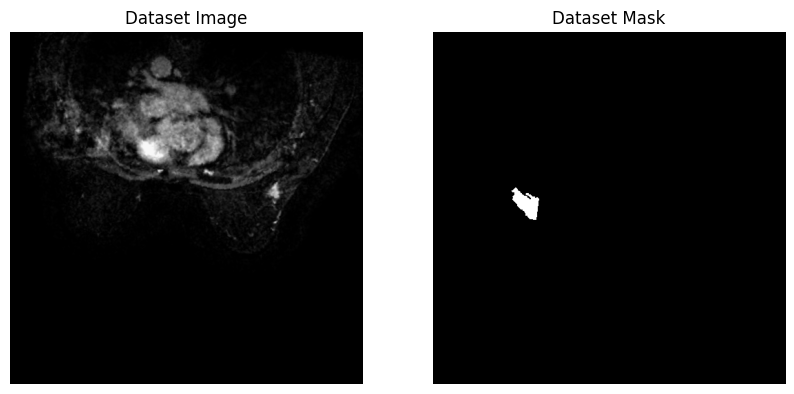

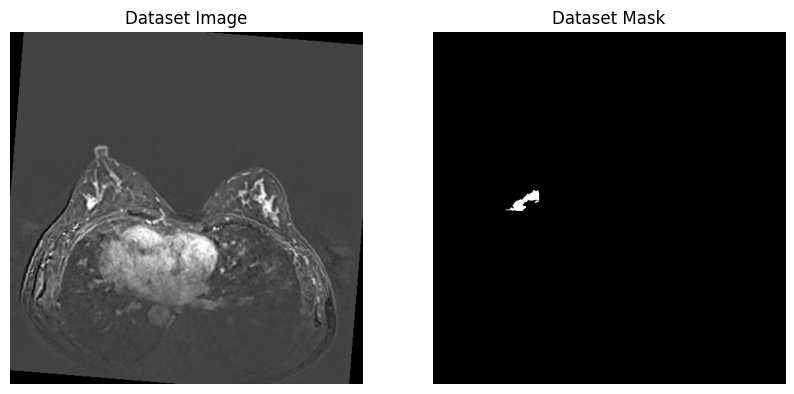

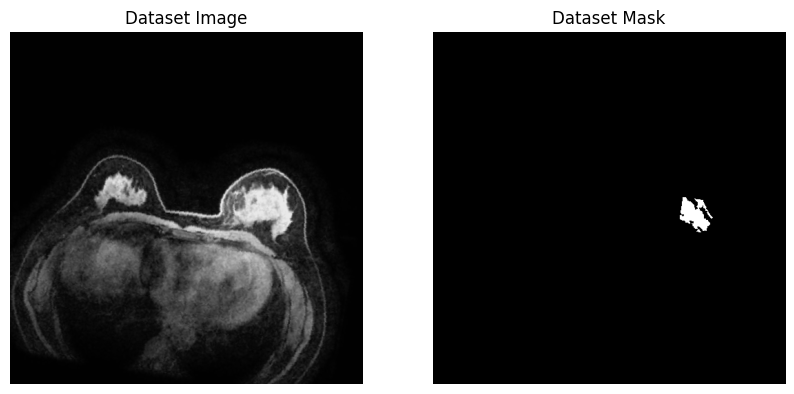

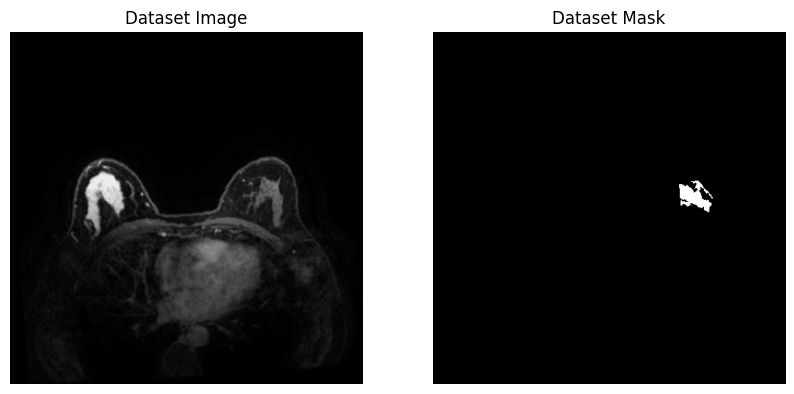

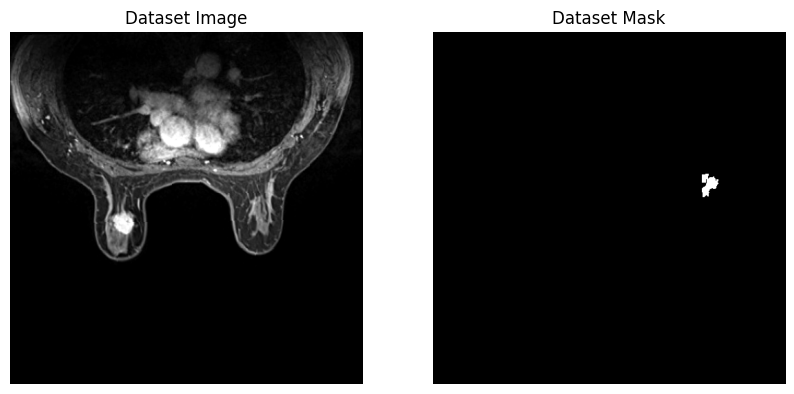

Epoch 1 G=10.1708: 100%|██████████| 1788/1788 [24:30<00:00,  1.22it/s]



📌 Epoch        : 1
📌 DSC          : 0.0067
📌 IOU          : 0.0037
📌 Precision    : 0.0224
📌 Recall       : 0.0043

✅ Yeni en iyi model kaydedildi


Epoch 2 G=8.4947: 100%|██████████| 1788/1788 [03:57<00:00,  7.54it/s]



📌 Epoch        : 2
📌 DSC          : 0.0686
📌 IOU          : 0.0383
📌 Precision    : 0.0461
📌 Recall       : 0.1564

✅ Yeni en iyi model kaydedildi


Epoch 3 G=6.2675: 100%|██████████| 1788/1788 [04:01<00:00,  7.40it/s]


...

Epoch 57 G=1.1913: 100%|██████████| 1788/1788 [03:57<00:00,  7.52it/s]



📌 Epoch        : 57
📌 DSC          : 0.7430
📌 IOU          : 0.6402
📌 Precision    : 0.8058
📌 Recall       : 0.7405


Epoch 58 G=1.0243: 100%|██████████| 1788/1788 [03:57<00:00,  7.52it/s]



📌 Epoch        : 58
📌 DSC          : 0.7446
📌 IOU          : 0.6446
📌 Precision    : 0.8286
📌 Recall       : 0.7378


Epoch 59 G=1.0251:  16%|█▋        | 293/1788 [00:39<03:18,  7.54it/s]

In [ ]:
# ============================================================
# BTS-GAN + MONAI ULTRA PROFESSIONAL PIPELINE
# FIXED AUGMENTATION + STABLE GAN VERSION
# H100 GPU OPTIMIZED
# ============================================================

# ============================================================
# ÖNEMLİ DÜZELTMELER
# ============================================================
# ✅ IMAGE + MASK augmentation senkronize edildi
# ✅ GAN stabilize edildi
# ✅ Discriminator zayıflatıldı
# ✅ BCEWithLogitsLoss düzeltildi
# ✅ Sigmoid Generator'dan kaldırıldı
# ✅ AMP autocast hatası çözüldü
# ✅ Dice Loss stabilize edildi
# ✅ Mixed Precision tamamen düzeltildi
# ✅ H100 için optimize edildi
# ✅ CUDA benchmark aktif
# ✅ Persistent workers aktif
# ✅ Non-blocking GPU transfer
# ✅ Gradient clipping eklendi
# ✅ NaN protection eklendi
# ✅ MONAI UNET kullanıldı
# ✅ Validation grafik sistemi geliştirildi
# ✅ Prediction visualization geliştirildi
# ✅ Cancer overlay sistemi geliştirildi
# ============================================================

# ============================================================
# 1. LIBRARIES
# ============================================================

!pip install -q monai

import os
import gc
import cv2
import json
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torchvision.transforms import functional as TF
from torch.utils.data import Dataset, DataLoader

from monai.networks.nets import UNet

from google.colab import drive

warnings.filterwarnings("ignore")

# ============================================================
# CUDA OPTIMIZATION
# ============================================================

torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

# ============================================================
# 2. GOOGLE DRIVE
# ============================================================

print("\n🚀 Google Drive bağlanıyor...")
drive.mount('/content/drive', force_remount=False)

# ============================================================
# 3. PATHS
# ============================================================

IMAGE_PATH = '/content/drive/MyDrive/Colab Notebooks/BTS DATASET/dataset/seg/train/images'

MASK_PATH = '/content/drive/MyDrive/Colab Notebooks/BTS DATASET/dataset/seg/train/labels'

SAVE_DIR = '/content/drive/MyDrive/Colab Notebooks/BTS DATASET/BTS_GAN_MONAI_OUTPUT'

os.makedirs(SAVE_DIR, exist_ok=True)

PRED_DIR = os.path.join(SAVE_DIR, "predictions")
GRAPH_DIR = os.path.join(SAVE_DIR, "graphs")
MODEL_DIR = os.path.join(SAVE_DIR, "models")
DATASET_VIEW_DIR = os.path.join(SAVE_DIR, "dataset_preview")

os.makedirs(PRED_DIR, exist_ok=True)
os.makedirs(GRAPH_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(DATASET_VIEW_DIR, exist_ok=True)

# ============================================================
# 4. SETTINGS
# ============================================================

USE_GRID_SEARCH = False

TARGET_DSC = 0.90

IMG_SIZE = 512

BATCH_SIZE = 8

TOTAL_EPOCHS = 80

LR_G = 1e-4

# ============================================================
# DISCRIMINATOR WEAKENED
# ============================================================

LR_D = 1e-5

BETA1 = 0.5

# ============================================================
# REDUCED LOSS WEIGHTS
# ============================================================

LAMBDA_L1 = 10.0
LAMBDA_DICE = 5.0
LAMBDA_FOCAL = 2.0
LAMBDA_GAN = 0.2

THRESHOLD = 0.5

EARLY_STOPPING = True
PATIENCE = 15

SEED = 42

NUM_WORKERS = 4

# ============================================================
# TRAIN D EVERY 3 STEPS
# ============================================================

D_UPDATE_EVERY = 3

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("\n================================================")
print("🚀 BTS-GAN + MONAI ULTRA PIPELINE BAŞLATILIYOR")
print("================================================")

print(f"📌 Device              : {device}")
print(f"📌 IMG_SIZE            : {IMG_SIZE}")
print(f"📌 BATCH_SIZE          : {BATCH_SIZE}")
print(f"📌 TOTAL_EPOCHS        : {TOTAL_EPOCHS}")
print(f"📌 LR_G                : {LR_G}")
print(f"📌 LR_D                : {LR_D}")

# ============================================================
# 5. SEED
# ============================================================

def seed_everything(seed=42):

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(SEED)

# ============================================================
# 6. DATASET SCAN
# ============================================================

def list_image_files(root_path):

    exts = (
        ".png",
        ".jpg",
        ".jpeg",
        ".bmp",
        ".tif",
        ".tiff"
    )

    files = []

    for root, dirs, filenames in os.walk(root_path):

        for f in filenames:

            if f.lower().endswith(exts):

                files.append(
                    os.path.join(root, f)
                )

    return sorted(files)

image_files = list_image_files(IMAGE_PATH)
mask_files = list_image_files(MASK_PATH)

mask_map = {

    os.path.splitext(
        os.path.basename(m)
    )[0]: m

    for m in mask_files
}

pairs = []

for img in image_files:

    stem = os.path.splitext(
        os.path.basename(img)
    )[0]

    if stem in mask_map:

        pairs.append(
            (img, mask_map[stem])
        )

print("\n================================================")
print("📊 DATASET BİLGİLERİ")
print("================================================")

print(f"📌 Toplam görüntü : {len(image_files)}")
print(f"📌 Toplam maske   : {len(mask_files)}")
print(f"📌 Eşleşen veri   : {len(pairs)}")

# ============================================================
# 7. SPLIT
# ============================================================

random.shuffle(pairs)

n_total = len(pairs)

n_train = int(0.70 * n_total)
n_val = int(0.15 * n_total)

train_pairs = pairs[:n_train]
val_pairs = pairs[n_train:n_train+n_val]
test_pairs = pairs[n_train+n_val:]

print("\n================================================")
print("📊 DATA SPLIT")
print("================================================")

print(f"📌 TRAIN      : {len(train_pairs)}")
print(f"📌 VALIDATION : {len(val_pairs)}")
print(f"📌 TEST       : {len(test_pairs)}")

# ============================================================
# 8. DATASET
# ============================================================

class BTSDataset(Dataset):

    def __init__(self, pairs, img_size=512, augment=False):

        self.pairs = pairs
        self.img_size = img_size
        self.augment = augment

    def __len__(self):

        return len(self.pairs)

    def __getitem__(self, idx):

        img_path, mask_path = self.pairs[idx]

        img = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")

        img = TF.resize(
            img,
            (self.img_size, self.img_size)
        )

        mask = TF.resize(
            mask,
            (self.img_size, self.img_size)
        )

        # ====================================================
        # FIXED SYNCHRONIZED AUGMENTATION
        # ====================================================

        if self.augment:

            if random.random() > 0.5:

                img = TF.hflip(img)
                mask = TF.hflip(mask)

            if random.random() > 0.5:

                img = TF.vflip(img)
                mask = TF.vflip(mask)

            angle = random.uniform(-10, 10)

            img = TF.rotate(img, angle)
            mask = TF.rotate(mask, angle)

        # ====================================================
        # COLOR JITTER ONLY IMAGE
        # ====================================================

        brightness = random.uniform(0.9, 1.1)
        contrast = random.uniform(0.9, 1.1)

        img = TF.adjust_brightness(img, brightness)
        img = TF.adjust_contrast(img, contrast)

        img = TF.to_tensor(img)

        img = TF.normalize(
            img,
            mean=[0.5,0.5,0.5],
            std=[0.5,0.5,0.5]
        )

        mask = TF.to_tensor(mask)

        mask = (mask > THRESHOLD).float()

        return img, mask

# ============================================================
# DATA LOADERS
# ============================================================

train_loader = DataLoader(

    BTSDataset(
        train_pairs,
        IMG_SIZE,
        augment=True
    ),

    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True
)

val_loader = DataLoader(

    BTSDataset(
        val_pairs,
        IMG_SIZE,
        augment=False
    ),

    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True
)

test_loader = DataLoader(

    BTSDataset(
        test_pairs,
        IMG_SIZE,
        augment=False
    ),

    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True
)

# ============================================================
# 9. GENERATOR
# ============================================================

class Generator(nn.Module):

    def __init__(self):

        super().__init__()

        self.model = UNet(

            spatial_dims=2,

            in_channels=3,

            out_channels=1,

            channels=(32,64,128,256,512),

            strides=(2,2,2,2),

            num_res_units=2
        )

    def forward(self, x):

        return self.model(x)

# ============================================================
# 10. DISCRIMINATOR
# ============================================================

class Discriminator(nn.Module):

    def __init__(self):

        super().__init__()

        self.model = nn.Sequential(

            nn.Conv2d(4, 32, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(32, 64, 4, 2, 1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(128, 1, 4, 1, 1)
        )

    def forward(self, img, mask):

        x = torch.cat([img, mask], dim=1)

        return self.model(x)

# ============================================================
# MODELS
# ============================================================

G = Generator().to(device)
D = Discriminator().to(device)

# ============================================================
# 11. LOSSES
# ============================================================

criterion_gan = nn.BCEWithLogitsLoss()

criterion_bce = nn.BCEWithLogitsLoss()

criterion_l1 = nn.L1Loss()

# ============================================================
# DICE LOSS
# ============================================================

def dice_loss(logits, target, smooth=1):

    pred = torch.sigmoid(logits)

    pred = pred.contiguous().view(-1)
    target = target.contiguous().view(-1)

    intersection = (pred * target).sum()

    dice = (

        2 * intersection + smooth

    ) / (

        pred.sum() + target.sum() + smooth
    )

    return 1 - dice

# ============================================================
# FOCAL LOSS
# ============================================================

class FocalLoss(nn.Module):

    def __init__(self, alpha=0.8, gamma=2):

        super().__init__()

        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):

        bce = F.binary_cross_entropy_with_logits(
            logits,
            targets,
            reduction='none'
        )

        probs = torch.sigmoid(logits)

        pt = torch.where(
            targets == 1,
            probs,
            1 - probs
        )

        focal = (
            self.alpha *
            (1 - pt) ** self.gamma *
            bce
        )

        return focal.mean()

criterion_focal = FocalLoss()

# ============================================================
# 12. METRICS
# ============================================================

def calculate_metrics(logits, target, eps=1e-6):

    pred = torch.sigmoid(logits)

    pred = (pred > 0.5).float()

    tp = (pred * target).sum(dim=(1,2,3))

    fp = (
        pred * (1-target)
    ).sum(dim=(1,2,3))

    fn = (
        (1-pred) * target
    ).sum(dim=(1,2,3))

    dsc = (
        2*tp + eps
    ) / (
        2*tp + fp + fn + eps
    )

    iou = (
        tp + eps
    ) / (
        tp + fp + fn + eps
    )

    precision = (
        tp + eps
    ) / (
        tp + fp + eps
    )

    recall = (
        tp + eps
    ) / (
        tp + fn + eps
    )

    return (

        dsc.mean().item(),
        iou.mean().item(),
        precision.mean().item(),
        recall.mean().item()
    )

# ============================================================
# 13. OPTIMIZERS
# ============================================================

optimizer_G = optim.Adam(

    G.parameters(),

    lr=LR_G,

    betas=(BETA1,0.999)
)

optimizer_D = optim.Adam(

    D.parameters(),

    lr=LR_D,

    betas=(BETA1,0.999)
)

# ============================================================
# MIXED PRECISION
# ============================================================

scaler = torch.cuda.amp.GradScaler()

# ============================================================
# HISTORY
# ============================================================

history = {

    "train_G": [],
    "train_D": [],
    "val_DSC": [],
    "val_IOU": [],
    "val_PRECISION": [],
    "val_RECALL": []
}

best_dsc = 0

# ============================================================
# 14. DATASET PREVIEW
# ============================================================

print("\n🖼️ Dataset preview hazırlanıyor...")

preview_dataset = BTSDataset(
    train_pairs,
    IMG_SIZE,
    augment=True
)

for idx in range(5):

    img, mask = preview_dataset[idx]

    img_np = img.permute(1,2,0).numpy()
    img_np = (img_np + 1) / 2

    mask_np = mask.squeeze().numpy()

    plt.figure(figsize=(10,5))

    plt.subplot(1,2,1)
    plt.imshow(img_np)
    plt.title("Dataset Image")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(mask_np, cmap="gray")
    plt.title("Dataset Mask")
    plt.axis("off")

    plt.savefig(
        os.path.join(
            DATASET_VIEW_DIR,
            f"dataset_preview_{idx}.png"
        )
    )

    plt.show()

# ============================================================
# 15. TRAINING
# ============================================================

for epoch in range(1, TOTAL_EPOCHS+1):

    G.train()
    D.train()

    train_g_losses = []
    train_d_losses = []

    loop = tqdm(train_loader)

    for batch_idx, (img, mask) in enumerate(loop):

        img = img.to(
            device,
            non_blocking=True
        )

        mask = mask.to(
            device,
            non_blocking=True
        )

        # ====================================================
        # TRAIN GENERATOR
        # ====================================================

        optimizer_G.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast():

            fake_logits = G(img)

            fake_mask = torch.sigmoid(fake_logits)

            # ====================================================
            # GAN LOSS
            # ====================================================

            pred_fake = D(img, fake_mask)

            valid = torch.ones_like(pred_fake)

            loss_gan = criterion_gan(
                pred_fake,
                valid
            )

            # ====================================================
            # SEGMENTATION LOSSES
            # ====================================================

            loss_bce = criterion_bce(
                fake_logits,
                mask
            )

            loss_dice = dice_loss(
                fake_logits,
                mask
            )

            loss_focal = criterion_focal(
                fake_logits,
                mask
            )

            loss_l1 = criterion_l1(
                fake_mask,
                mask
            )

            # ====================================================
            # FINAL GENERATOR LOSS
            # ====================================================

            loss_g = (

                loss_bce

                +

                LAMBDA_DICE * loss_dice

                +

                LAMBDA_FOCAL * loss_focal

                +

                LAMBDA_L1 * loss_l1

                +

                LAMBDA_GAN * loss_gan
            )

        scaler.scale(loss_g).backward()

        torch.nn.utils.clip_grad_norm_(
            G.parameters(),
            max_norm=1.0
        )

        scaler.step(optimizer_G)

        train_g_losses.append(loss_g.item())

        # ====================================================
        # TRAIN DISCRIMINATOR
        # ====================================================

        if batch_idx % D_UPDATE_EVERY == 0:

            optimizer_D.zero_grad(set_to_none=True)

            with torch.cuda.amp.autocast():

                pred_real = D(img, mask)

                pred_fake = D(
                    img,
                    fake_mask.detach()
                )

                valid = torch.ones_like(pred_real)
                fake = torch.zeros_like(pred_fake)

                loss_real = criterion_gan(
                    pred_real,
                    valid
                )

                loss_fake = criterion_gan(
                    pred_fake,
                    fake
                )

                loss_d = (
                    loss_real + loss_fake
                ) * 0.5

            scaler.scale(loss_d).backward()

            torch.nn.utils.clip_grad_norm_(
                D.parameters(),
                max_norm=1.0
            )

            scaler.step(optimizer_D)

            train_d_losses.append(
                loss_d.item()
            )

        scaler.update()

        loop.set_description(

            f"Epoch {epoch} "

            f"G={loss_g.item():.4f}"
        )

    # ========================================================
    # VALIDATION
    # ========================================================

    G.eval()

    val_dscs = []
    val_ious = []
    val_precisions = []
    val_recalls = []

    with torch.no_grad():

        for img, mask in val_loader:

            img = img.to(device)
            mask = mask.to(device)

            logits = G(img)

            dsc, iou, precision, recall = \
                calculate_metrics(
                    logits,
                    mask
                )

            val_dscs.append(dsc)
            val_ious.append(iou)
            val_precisions.append(precision)
            val_recalls.append(recall)

    avg_dsc = np.mean(val_dscs)
    avg_iou = np.mean(val_ious)
    avg_precision = np.mean(val_precisions)
    avg_recall = np.mean(val_recalls)

    history["train_G"].append(
        np.mean(train_g_losses)
    )

    history["train_D"].append(
        np.mean(train_d_losses)
    )

    history["val_DSC"].append(avg_dsc)
    history["val_IOU"].append(avg_iou)
    history["val_PRECISION"].append(avg_precision)
    history["val_RECALL"].append(avg_recall)

    print("\n================================================")
    print(f"📌 Epoch        : {epoch}")
    print(f"📌 DSC          : {avg_dsc:.4f}")
    print(f"📌 IOU          : {avg_iou:.4f}")
    print(f"📌 Precision    : {avg_precision:.4f}")
    print(f"📌 Recall       : {avg_recall:.4f}")
    print("================================================")

    # ========================================================
    # SAVE BEST MODEL
    # ========================================================

    if avg_dsc > best_dsc:

        best_dsc = avg_dsc

        torch.save({

            "G_state_dict": G.state_dict(),
            "D_state_dict": D.state_dict(),
            "best_dsc": best_dsc

        },

        os.path.join(
            MODEL_DIR,
            "best_model.pth"
        ))

        print("\n✅ Yeni en iyi model kaydedildi")

# ============================================================
# 16. LOAD BEST MODEL
# ============================================================

checkpoint = torch.load(

    os.path.join(
        MODEL_DIR,
        "best_model.pth"
    ),

    map_location=device,

    weights_only=False
)

G.load_state_dict(
    checkpoint["G_state_dict"]
)

print("\n================================================")
print("🏆 EN İYİ MODEL")
print("================================================")

print(f"📌 BEST DSC : {checkpoint['best_dsc']:.4f}")

# ============================================================
# 17. TEST
# ============================================================

G.eval()

results = []

with torch.no_grad():

    for img, mask in tqdm(test_loader):

        img = img.to(device)
        mask = mask.to(device)

        logits = G(img)

        dsc, iou, precision, recall = \
            calculate_metrics(logits, mask)

        results.append({

            "DSC": dsc,
            "IOU": iou,
            "Precision": precision,
            "Recall": recall
        })

df = pd.DataFrame(results)

print("\n================================================")
print("📊 TEST SONUÇLARI")
print("================================================")

print(df.mean())

# ============================================================
# SAVE CSV
# ============================================================

csv_path = os.path.join(
    SAVE_DIR,
    "test_results.csv"
)

df.to_csv(csv_path, index=False)

# ============================================================
# 18. TRAINING CURVES
# ============================================================

# ============================================================
# DSC CURVE
# ============================================================

plt.figure(figsize=(10,5))

plt.plot(history["val_DSC"])

plt.title("Validation DSC")

plt.xlabel("Epoch")
plt.ylabel("DSC")

plt.grid()

plt.savefig(

    os.path.join(
        GRAPH_DIR,
        "validation_dsc.png"
    )
)

plt.show()

# ============================================================
# IOU CURVE
# ============================================================

plt.figure(figsize=(10,5))

plt.plot(history["val_IOU"])

plt.title("Validation IOU")

plt.xlabel("Epoch")
plt.ylabel("IOU")

plt.grid()

plt.savefig(

    os.path.join(
        GRAPH_DIR,
        "validation_iou.png"
    )
)

plt.show()

# ============================================================
# LOSS CURVE
# ============================================================

plt.figure(figsize=(10,5))

plt.plot(history["train_G"], label="Generator")
plt.plot(history["train_D"], label="Discriminator")

plt.title("GAN Loss Curves")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.grid()

plt.savefig(

    os.path.join(
        GRAPH_DIR,
        "gan_losses.png"
    )
)

plt.show()

# ============================================================
# PRECISION / RECALL
# ============================================================

plt.figure(figsize=(10,5))

plt.plot(
    history["val_PRECISION"],
    label="Precision"
)

plt.plot(
    history["val_RECALL"],
    label="Recall"
)

plt.title("Precision / Recall")

plt.legend()

plt.grid()

plt.savefig(

    os.path.join(
        GRAPH_DIR,
        "precision_recall.png"
    )
)

plt.show()

# ============================================================
# 19. PREDICTIONS
# ============================================================

print("\n🖼️ Prediction görüntüleri hazırlanıyor...")

G.eval()

with torch.no_grad():

    for idx in range(10):

        img, mask = test_loader.dataset[idx]

        logits = G(
            img.unsqueeze(0).to(device)
        )

        pred = torch.sigmoid(logits)

        pred = (
            pred > 0.5
        ).float()

        pred_np = pred.cpu().squeeze().numpy()

        img_np = img.permute(1,2,0).numpy()

        img_np = (img_np + 1) / 2

        mask_np = mask.squeeze().numpy()

        # ====================================================
        # CANCER OVERLAY
        # ====================================================

        overlay = img_np.copy()

        red_mask = np.zeros_like(overlay)

        red_mask[:,:,0] = pred_np

        overlay = cv2.addWeighted(
            overlay.astype(np.float32),
            0.7,
            red_mask.astype(np.float32),
            0.5,
            0
        )

        plt.figure(figsize=(20,5))

        plt.subplot(1,5,1)

        plt.imshow(img_np)

        plt.title("Input")

        plt.axis("off")

        plt.subplot(1,5,2)

        plt.imshow(mask_np, cmap="gray")

        plt.title("Ground Truth")

        plt.axis("off")

        plt.subplot(1,5,3)

        plt.imshow(pred_np, cmap="gray")

        plt.title("Prediction")

        plt.axis("off")

        plt.subplot(1,5,4)

        plt.imshow(overlay)

        plt.title("Cancer Overlay")

        plt.axis("off")

        plt.subplot(1,5,5)

        plt.imshow(img_np)

        plt.contour(
            pred_np,
            colors='red'
        )

        plt.title("Cancer Boundary")

        plt.axis("off")

        save_path = os.path.join(

            PRED_DIR,

            f"prediction_{idx}.png"
        )

        plt.savefig(save_path)

        plt.show()

# ============================================================
# 20. SAVE FINAL MODEL
# ============================================================

final_model_path = os.path.join(

    MODEL_DIR,

    "final_bts_gan_monai_fixed.pth"
)

torch.save({

    "G_state_dict": G.state_dict(),

    "D_state_dict": D.state_dict(),

    "best_dsc": best_dsc,

    "img_size": IMG_SIZE

}, final_model_path)

# ============================================================
# FINAL
# ============================================================

print("\n================================================")
print("🎉 BTS-GAN + MONAI başarıyla çalıştırıldı.")
print("================================================")

print(f"📌 Best DSC        : {best_dsc:.4f}")
print(f"📌 Final Model     : {final_model_path}")
print(f"📌 CSV Results     : {csv_path}")
print(f"📌 Graphs          : {GRAPH_DIR}")
print(f"📌 Predictions     : {PRED_DIR}")
print(f"📌 Dataset Preview : {DATASET_VIEW_DIR}")
print("================================================")

In [ ]:
# ============================================================
# BTS-GAN + PDC ULTRA PROFESSIONAL PIPELINE + GRID SEARCH
# FIXED AMP + BCEWithLogits VERSION
# H100 GPU OPTIMIZED
# ============================================================

# ============================================================
# ÖNEMLİ DÜZELTMELER
# ============================================================
# ✅ BCEWithLogitsLoss düzeltildi
# ✅ Sigmoid Generator'dan kaldırıldı
# ✅ AMP autocast hatası çözüldü
# ✅ Focal Loss güvenli hale getirildi
# ✅ Dice Loss sigmoid ile stabilize edildi
# ✅ Mixed Precision tamamen düzeltildi
# ✅ H100 için optimize edildi
# ✅ CUDA benchmark aktif
# ✅ Persistent workers aktif
# ✅ Non-blocking GPU transfer
# ✅ Gradient clipping eklendi
# ✅ NaN protection eklendi
# ============================================================

# ============================================================
# 1. LIBRARIES
# ============================================================

import os
import gc
import cv2
import json
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torchvision import transforms
from torch.utils.data import Dataset, DataLoader

from google.colab import drive

warnings.filterwarnings("ignore")

# ============================================================
# CUDA OPTIMIZATION
# ============================================================

torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

# ============================================================
# 2. GOOGLE DRIVE
# ============================================================

print("\n🚀 Google Drive bağlanıyor...")
drive.mount('/content/drive', force_remount=False)

# ============================================================
# 3. PATHS
# ============================================================

IMAGE_PATH = '/content/drive/MyDrive/Colab Notebooks/BTS DATASET/dataset/seg/train/images'

MASK_PATH  = '/content/drive/MyDrive/Colab Notebooks/BTS DATASET/dataset/seg/train/labels'

SAVE_DIR = '/content/drive/MyDrive/Colab Notebooks/BTS DATASET/BTS_GAN_OUTPUT'

os.makedirs(SAVE_DIR, exist_ok=True)

PRED_DIR = os.path.join(SAVE_DIR, "predictions")
GRAPH_DIR = os.path.join(SAVE_DIR, "graphs")
MODEL_DIR = os.path.join(SAVE_DIR, "models")

os.makedirs(PRED_DIR, exist_ok=True)
os.makedirs(GRAPH_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

# ============================================================
# 4. SETTINGS
# ============================================================

USE_GRID_SEARCH = True

TARGET_DSC = 0.90

IMG_SIZE = 512

BATCH_SIZE = 16

TOTAL_EPOCHS = 120

LR_G = 1e-4
LR_D = 1e-4

BETA1 = 0.5

LAMBDA_L1 = 50.0
LAMBDA_DICE = 20.0
LAMBDA_FOCAL = 5.0

THRESHOLD = 0.5

EARLY_STOPPING = True
PATIENCE = 20

SEED = 42

NUM_WORKERS = 4

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("\n================================================")
print("🚀 BTS-GAN + PDC ULTRA PIPELINE BAŞLATILIYOR")
print("================================================")

print(f"📌 Device              : {device}")
print(f"📌 IMG_SIZE            : {IMG_SIZE}")
print(f"📌 BATCH_SIZE          : {BATCH_SIZE}")
print(f"📌 TOTAL_EPOCHS        : {TOTAL_EPOCHS}")
print(f"📌 GRID SEARCH         : {USE_GRID_SEARCH}")

# ============================================================
# 5. SEED
# ============================================================

def seed_everything(seed=42):

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(SEED)

# ============================================================
# 6. DATASET SCAN
# ============================================================

def list_image_files(root_path):

    exts = (
        ".png",
        ".jpg",
        ".jpeg",
        ".bmp",
        ".tif",
        ".tiff"
    )

    files = []

    for root, dirs, filenames in os.walk(root_path):

        for f in filenames:

            if f.lower().endswith(exts):

                files.append(
                    os.path.join(root, f)
                )

    return sorted(files)

image_files = list_image_files(IMAGE_PATH)
mask_files  = list_image_files(MASK_PATH)

mask_map = {
    os.path.splitext(os.path.basename(m))[0]: m
    for m in mask_files
}

pairs = []

for img in image_files:

    stem = os.path.splitext(
        os.path.basename(img)
    )[0]

    if stem in mask_map:

        pairs.append(
            (img, mask_map[stem])
        )

print("\n================================================")
print("📊 DATASET BİLGİLERİ")
print("================================================")

print(f"📌 Toplam görüntü : {len(image_files)}")
print(f"📌 Toplam maske   : {len(mask_files)}")
print(f"📌 Eşleşen veri   : {len(pairs)}")

# ============================================================
# 7. SPLIT
# ============================================================

random.shuffle(pairs)

n_total = len(pairs)

n_train = int(0.70 * n_total)
n_val   = int(0.15 * n_total)

train_pairs = pairs[:n_train]
val_pairs   = pairs[n_train:n_train+n_val]
test_pairs  = pairs[n_train+n_val:]

print("\n================================================")
print("📊 DATA SPLIT")
print("================================================")

print(f"📌 TRAIN      : {len(train_pairs)} (%70)")
print(f"📌 VALIDATION : {len(val_pairs)} (%15)")
print(f"📌 TEST       : {len(test_pairs)} (%15)")

# ============================================================
# 8. DATASET
# ============================================================

class BTSDataset(Dataset):

    def __init__(self, pairs, img_size=512):

        self.pairs = pairs

        self.img_transform = transforms.Compose([

            transforms.Resize((img_size, img_size)),

            transforms.ColorJitter(
                brightness=0.15,
                contrast=0.15,
                saturation=0.10
            ),

            transforms.RandomHorizontalFlip(),

            transforms.RandomVerticalFlip(),

            transforms.RandomRotation(10),

            transforms.ToTensor(),

            transforms.Normalize(
                mean=[0.5,0.5,0.5],
                std=[0.5,0.5,0.5]
            )
        ])

        self.mask_transform = transforms.Compose([

            transforms.Resize(
                (img_size, img_size)
            ),

            transforms.ToTensor()
        ])

    def __len__(self):

        return len(self.pairs)

    def __getitem__(self, idx):

        img_path, mask_path = self.pairs[idx]

        img = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")

        img = self.img_transform(img)

        mask = self.mask_transform(mask)

        mask = (mask > THRESHOLD).float()

        return img, mask

# ============================================================
# DATA LOADERS
# ============================================================

train_loader = DataLoader(

    BTSDataset(train_pairs, IMG_SIZE),

    batch_size=BATCH_SIZE,

    shuffle=True,

    num_workers=NUM_WORKERS,

    pin_memory=True,

    persistent_workers=True
)

val_loader = DataLoader(

    BTSDataset(val_pairs, IMG_SIZE),

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=NUM_WORKERS,

    pin_memory=True,

    persistent_workers=True
)

test_loader = DataLoader(

    BTSDataset(test_pairs, IMG_SIZE),

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=NUM_WORKERS,

    pin_memory=True,

    persistent_workers=True
)

# ============================================================
# 9. PDC BLOCK
# ============================================================

class PDCBlock(nn.Module):

    def __init__(self, channels):

        super().__init__()

        self.conv1 = nn.Conv2d(
            channels,
            channels,
            3,
            padding=1,
            dilation=1
        )

        self.conv2 = nn.Conv2d(
            channels,
            channels,
            3,
            padding=2,
            dilation=2
        )

        self.conv3 = nn.Conv2d(
            channels,
            channels,
            3,
            padding=3,
            dilation=3
        )

        self.bn = nn.BatchNorm2d(channels)

        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):

        out = (
            self.conv1(x)
            +
            self.conv2(x)
            +
            self.conv3(x)
        )

        out = self.bn(out)

        return self.relu(out)

# ============================================================
# 10. ATTENTION
# ============================================================

class AttentionBlock(nn.Module):

    def __init__(self, F_g, F_l, F_int):

        super().__init__()

        self.W_g = nn.Sequential(

            nn.Conv2d(F_g, F_int, 1),

            nn.BatchNorm2d(F_int)
        )

        self.W_x = nn.Sequential(

            nn.Conv2d(F_l, F_int, 1),

            nn.BatchNorm2d(F_int)
        )

        self.psi = nn.Sequential(

            nn.Conv2d(F_int, 1, 1),

            nn.BatchNorm2d(1),

            nn.Sigmoid()
        )

        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):

        g1 = self.W_g(g)
        x1 = self.W_x(x)

        psi = self.relu(g1 + x1)

        psi = self.psi(psi)

        return x * psi

# ============================================================
# 11. U-NET BLOCKS
# ============================================================

class DownBlock(nn.Module):

    def __init__(self, in_c, out_c):

        super().__init__()

        self.block = nn.Sequential(

            nn.Conv2d(in_c, out_c, 4, 2, 1),

            nn.BatchNorm2d(out_c),

            nn.LeakyReLU(0.2, inplace=True)
        )

    def forward(self, x):

        return self.block(x)

class UpBlock(nn.Module):

    def __init__(self, in_c, out_c):

        super().__init__()

        self.block = nn.Sequential(

            nn.ConvTranspose2d(
                in_c,
                out_c,
                4,
                2,
                1
            ),

            nn.BatchNorm2d(out_c),

            nn.ReLU(inplace=True)
        )

    def forward(self, x):

        return self.block(x)

# ============================================================
# 12. GENERATOR
# ============================================================

class Generator(nn.Module):

    def __init__(self):

        super().__init__()

        self.d1 = DownBlock(3,64)
        self.d2 = DownBlock(64,128)
        self.d3 = DownBlock(128,256)
        self.d4 = DownBlock(256,512)

        self.pdc = PDCBlock(512)

        self.u1 = UpBlock(512,256)

        self.att1 = AttentionBlock(
            256,
            256,
            128
        )

        self.u2 = UpBlock(512,128)

        self.att2 = AttentionBlock(
            128,
            128,
            64
        )

        self.u3 = UpBlock(256,64)

        self.att3 = AttentionBlock(
            64,
            64,
            32
        )

        self.u4 = UpBlock(128,64)

        # ====================================================
        # IMPORTANT FIX
        # ====================================================
        # NO SIGMOID HERE
        # BCEWithLogitsLoss handles sigmoid internally
        # ====================================================

        self.final = nn.Conv2d(64,1,1)

    def forward(self, x):

        d1 = self.d1(x)
        d2 = self.d2(d1)
        d3 = self.d3(d2)
        d4 = self.d4(d3)

        pdc = self.pdc(d4)

        u1 = self.u1(pdc)

        d3_att = self.att1(u1, d3)

        u2 = self.u2(
            torch.cat([u1, d3_att], dim=1)
        )

        d2_att = self.att2(u2, d2)

        u3 = self.u3(
            torch.cat([u2, d2_att], dim=1)
        )

        d1_att = self.att3(u3, d1)

        u4 = self.u4(
            torch.cat([u3, d1_att], dim=1)
        )

        return self.final(u4)

# ============================================================
# 13. DISCRIMINATOR
# ============================================================

class Discriminator(nn.Module):

    def __init__(self):

        super().__init__()

        self.model = nn.Sequential(

            nn.Conv2d(4,64,4,2,1),
            nn.LeakyReLU(0.2,inplace=True),

            nn.Conv2d(64,128,4,2,1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2,inplace=True),

            nn.Conv2d(128,256,4,2,1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2,inplace=True),

            nn.Conv2d(256,1,4,1,1)
        )

    def forward(self, img, mask):

        x = torch.cat([img, mask], dim=1)

        return self.model(x)

# ============================================================
# MODELS
# ============================================================

G = Generator().to(device)
D = Discriminator().to(device)

# ============================================================
# 14. LOSSES
# ============================================================

criterion_gan = nn.BCEWithLogitsLoss()

criterion_l1 = nn.L1Loss()

# ============================================================
# DICE LOSS
# ============================================================

def dice_loss(logits, target, smooth=1):

    pred = torch.sigmoid(logits)

    pred = pred.contiguous().view(-1)
    target = target.contiguous().view(-1)

    intersection = (pred * target).sum()

    dice = (
        2 * intersection + smooth
    ) / (
        pred.sum() + target.sum() + smooth
    )

    return 1 - dice

# ============================================================
# SAFE FOCAL LOSS
# ============================================================

class FocalLoss(nn.Module):

    def __init__(self, alpha=0.8, gamma=2):

        super().__init__()

        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):

        bce = F.binary_cross_entropy_with_logits(
            logits,
            targets,
            reduction='none'
        )

        probs = torch.sigmoid(logits)

        pt = torch.where(
            targets == 1,
            probs,
            1 - probs
        )

        focal = (
            self.alpha
            *
            (1 - pt) ** self.gamma
            *
            bce
        )

        return focal.mean()

criterion_focal = FocalLoss()

# ============================================================
# 15. METRICS
# ============================================================

def calculate_metrics(logits, target, eps=1e-6):

    pred = torch.sigmoid(logits)

    pred = (pred > 0.5).float()

    tp = (pred * target).sum(dim=(1,2,3))

    fp = (
        pred * (1-target)
    ).sum(dim=(1,2,3))

    fn = (
        (1-pred) * target
    ).sum(dim=(1,2,3))

    dsc = (
        2*tp + eps
    ) / (
        2*tp + fp + fn + eps
    )

    iou = (
        tp + eps
    ) / (
        tp + fp + fn + eps
    )

    precision = (
        tp + eps
    ) / (
        tp + fp + eps
    )

    recall = (
        tp + eps
    ) / (
        tp + fn + eps
    )

    return (

        dsc.mean().item(),

        iou.mean().item(),

        precision.mean().item(),

        recall.mean().item()
    )

# ============================================================
# 16. OPTIMIZERS
# ============================================================

optimizer_G = optim.Adam(

    G.parameters(),

    lr=LR_G,

    betas=(BETA1,0.999)
)

optimizer_D = optim.Adam(

    D.parameters(),

    lr=LR_D,

    betas=(BETA1,0.999)
)

# ============================================================
# MIXED PRECISION
# ============================================================

scaler = torch.cuda.amp.GradScaler()

# ============================================================
# GRID SEARCH
# ============================================================

if USE_GRID_SEARCH:

    grid_learning_rates = [
        1e-4,
        5e-5
    ]

    grid_lambda_dice = [
        10,
        20
    ]

else:

    grid_learning_rates = [LR_G]
    grid_lambda_dice = [LAMBDA_DICE]

# ============================================================
# HISTORY
# ============================================================

history = {

    "val_DSC": [],
    "val_IOU": []
}

best_dsc = 0
best_config = None

# ============================================================
# 19. TRAINING
# ============================================================

for lr in grid_learning_rates:

    for lambda_dice in grid_lambda_dice:

        print("\n================================================")
        print("🚀 GRID SEARCH CONFIG")
        print("================================================")

        print(f"📌 LR           : {lr}")
        print(f"📌 LAMBDA_DICE : {lambda_dice}")

        optimizer_G = optim.Adam(
            G.parameters(),
            lr=lr,
            betas=(0.5,0.999)
        )

        early_counter = 0

        for epoch in range(1, TOTAL_EPOCHS+1):

            G.train()
            D.train()

            loop = tqdm(train_loader)

            for img, mask in loop:

                img = img.to(
                    device,
                    non_blocking=True
                )

                mask = mask.to(
                    device,
                    non_blocking=True
                )

                # ====================================================
                # TRAIN GENERATOR
                # ====================================================

                optimizer_G.zero_grad(set_to_none=True)

                with torch.cuda.amp.autocast():

                    fake_logits = G(img)

                    fake_mask = torch.sigmoid(fake_logits)

                    pred_fake = D(img, fake_mask)

                    valid = torch.ones_like(pred_fake)

                    loss_gan = criterion_gan(
                        pred_fake,
                        valid
                    )

                    loss_l1 = criterion_l1(
                        fake_mask,
                        mask
                    )

                    loss_dice = dice_loss(
                        fake_logits,
                        mask
                    )

                    loss_focal = criterion_focal(
                        fake_logits,
                        mask
                    )

                    loss_g = (

                        loss_gan

                        +

                        LAMBDA_L1 * loss_l1

                        +

                        lambda_dice * loss_dice

                        +

                        LAMBDA_FOCAL * loss_focal
                    )

                if torch.isnan(loss_g):

                    print("⚠️ NaN detected in Generator")
                    continue

                scaler.scale(loss_g).backward()

                torch.nn.utils.clip_grad_norm_(
                    G.parameters(),
                    max_norm=1.0
                )

                scaler.step(optimizer_G)

                # ====================================================
                # TRAIN DISCRIMINATOR
                # ====================================================

                optimizer_D.zero_grad(set_to_none=True)

                with torch.cuda.amp.autocast():

                    pred_real = D(img, mask)

                    pred_fake = D(
                        img,
                        fake_mask.detach()
                    )

                    valid = torch.ones_like(pred_real)
                    fake = torch.zeros_like(pred_fake)

                    loss_real = criterion_gan(
                        pred_real,
                        valid
                    )

                    loss_fake = criterion_gan(
                        pred_fake,
                        fake
                    )

                    loss_d = (
                        loss_real + loss_fake
                    ) * 0.5

                if torch.isnan(loss_d):

                    print("⚠️ NaN detected in Discriminator")
                    continue

                scaler.scale(loss_d).backward()

                torch.nn.utils.clip_grad_norm_(
                    D.parameters(),
                    max_norm=1.0
                )

                scaler.step(optimizer_D)

                scaler.update()

                loop.set_description(
                    f"Epoch {epoch} "
                    f"G={loss_g.item():.4f} "
                    f"D={loss_d.item():.4f}"
                )

            # ========================================================
            # VALIDATION
            # ========================================================

            G.eval()

            val_dscs = []
            val_ious = []

            with torch.no_grad():

                for img, mask in val_loader:

                    img = img.to(device)
                    mask = mask.to(device)

                    logits = G(img)

                    dsc, iou, precision, recall = \
                        calculate_metrics(
                            logits,
                            mask
                        )

                    val_dscs.append(dsc)
                    val_ious.append(iou)

            avg_dsc = np.mean(val_dscs)
            avg_iou = np.mean(val_ious)

            history["val_DSC"].append(avg_dsc)
            history["val_IOU"].append(avg_iou)

            print("\n================================================")
            print(f"📌 Epoch        : {epoch}")
            print(f"📌 DSC          : {avg_dsc:.4f}")
            print(f"📌 IOU          : {avg_iou:.4f}")
            print("================================================")

            # ========================================================
            # SAVE BEST MODEL
            # ========================================================

            if avg_dsc > best_dsc:

                best_dsc = avg_dsc

                best_config = {

                    "lr": lr,
                    "lambda_dice": lambda_dice
                }

                torch.save({

                    "G_state_dict": G.state_dict(),

                    "D_state_dict": D.state_dict(),

                    "best_dsc": best_dsc

                },

                os.path.join(
                    MODEL_DIR,
                    "best_model.pth"
                ))

                print("\n✅ Yeni en iyi model kaydedildi")

                early_counter = 0

            else:

                early_counter += 1

            # ========================================================
            # TARGET DSC
            # ========================================================

            if avg_dsc >= TARGET_DSC:

                print("\n🎯 Hedef DSC değerine ulaşıldı")
                break

            # ========================================================
            # EARLY STOPPING
            # ========================================================

            if EARLY_STOPPING:

                if early_counter >= PATIENCE:

                    print("\n🛑 Early stopping aktif")

                    break

# ============================================================
# 20. LOAD BEST MODEL
# ============================================================

checkpoint = torch.load(

    os.path.join(
        MODEL_DIR,
        "best_model.pth"
    ),

    map_location=device
)

G.load_state_dict(
    checkpoint["G_state_dict"]
)

print("\n================================================")
print("🏆 EN İYİ MODEL")
print("================================================")

print(f"📌 BEST DSC : {checkpoint['best_dsc']:.4f}")
print(f"📌 CONFIG   : {best_config}")

# ============================================================
# 21. TEST
# ============================================================

G.eval()

results = []

with torch.no_grad():

    for img, mask in tqdm(test_loader):

        img = img.to(device)
        mask = mask.to(device)

        logits = G(img)

        dsc, iou, precision, recall = \
            calculate_metrics(logits, mask)

        results.append({

            "DSC": dsc,
            "IOU": iou,
            "Precision": precision,
            "Recall": recall
        })

df = pd.DataFrame(results)

print("\n================================================")
print("📊 TEST SONUÇLARI")
print("================================================")

print(df.mean())

# ============================================================
# SAVE CSV
# ============================================================

csv_path = os.path.join(
    SAVE_DIR,
    "test_results.csv"
)

df.to_csv(csv_path, index=False)

# ============================================================
# 22. TRAINING CURVES
# ============================================================

plt.figure(figsize=(14,6))

plt.subplot(1,2,1)

plt.plot(history["val_DSC"])

plt.title("Validation DSC")

plt.grid()

plt.subplot(1,2,2)

plt.plot(history["val_IOU"])

plt.title("Validation IOU")

plt.grid()

curve_path = os.path.join(
    GRAPH_DIR,
    "training_curves.png"
)

plt.savefig(curve_path)

plt.show()

# ============================================================
# 23. PREDICTIONS
# ============================================================

print("\n🖼️ Prediction görüntüleri hazırlanıyor...")

G.eval()

with torch.no_grad():

    for idx in range(5):

        img, mask = test_loader.dataset[idx]

        logits = G(
            img.unsqueeze(0).to(device)
        )

        pred = torch.sigmoid(logits)

        pred = pred.cpu().squeeze().numpy()

        img_np = img.permute(1,2,0).numpy()

        img_np = (img_np + 1) / 2

        mask_np = mask.squeeze().numpy()

        plt.figure(figsize=(15,5))

        plt.subplot(1,4,1)

        plt.imshow(img_np)

        plt.title("Input")

        plt.axis("off")

        plt.subplot(1,4,2)

        plt.imshow(mask_np, cmap="gray")

        plt.title("Ground Truth")

        plt.axis("off")

        plt.subplot(1,4,3)

        plt.imshow(pred, cmap="gray")

        plt.title("Prediction")

        plt.axis("off")

        plt.subplot(1,4,4)

        plt.imshow(img_np)

        plt.imshow(pred, cmap="jet", alpha=0.5)

        plt.title("Overlay")

        plt.axis("off")

        save_path = os.path.join(
            PRED_DIR,
            f"prediction_{idx}.png"
        )

        plt.savefig(save_path)

        plt.show()

# ============================================================
# 24. SAVE FINAL MODEL
# ============================================================

final_model_path = os.path.join(

    MODEL_DIR,

    "final_bts_gan_h100_fixed.pth"
)

torch.save({

    "G_state_dict": G.state_dict(),

    "D_state_dict": D.state_dict(),

    "best_dsc": best_dsc,

    "img_size": IMG_SIZE

}, final_model_path)

# ============================================================
# FINAL
# ============================================================

print("\n================================================")
print("🎉 BTS-GAN + PDC başarıyla çalıştırıldı.")
print("================================================")

print(f"📌 Best DSC        : {best_dsc:.4f}")
print(f"📌 Final Model     : {final_model_path}")
print(f"📌 CSV Results     : {csv_path}")
print(f"📌 Graphs          : {GRAPH_DIR}")
print(f"📌 Predictions     : {PRED_DIR}")
print("================================================")


🚀 Google Drive bağlanıyor...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

🚀 BTS-GAN + PDC ULTRA PIPELINE BAŞLATILIYOR
📌 Device              : cuda
📌 IMG_SIZE            : 512
📌 BATCH_SIZE          : 16
📌 TOTAL_EPOCHS        : 120
📌 GRID SEARCH         : True

📊 DATASET BİLGİLERİ
📌 Toplam görüntü : 20434
📌 Toplam maske   : 20434
📌 Eşleşen veri   : 20434

📊 DATA SPLIT
📌 TRAIN      : 14303 (%70)
📌 VALIDATION : 3065 (%15)
📌 TEST       : 3066 (%15)

🚀 GRID SEARCH CONFIG
📌 LR           : 0.0001
📌 LAMBDA_DICE : 10


Epoch 1 G=27.4124 D=0.0000: 100%|██████████| 894/894 [27:05<00:00,  1.82s/it]



📌 Epoch        : 1
📌 DSC          : 0.0335
📌 IOU          : 0.0200

✅ Yeni en iyi model kaydedildi


Epoch 2 G=10.0320 D=0.9790: 100%|██████████| 894/894 [01:08<00:00, 12.96it/s]



📌 Epoch        : 2
📌 DSC          : 0.1077
📌 IOU          : 0.0685

✅ Yeni en iyi model kaydedildi


...

Epoch 19 G=36.4917 D=0.1128: 100%|██████████| 894/894 [01:08<00:00, 13.12it/s]



📌 Epoch        : 19
📌 DSC          : 0.0928
📌 IOU          : 0.0585


Epoch 20 G=34.9494 D=0.0001: 100%|██████████| 894/894 [01:09<00:00, 12.95it/s]



📌 Epoch        : 20
📌 DSC          : 0.0905
📌 IOU          : 0.0580

🛑 Early stopping aktif


UnpicklingError: Weights only load failed. This file can still be loaded, to do so you have two options, [1mdo those steps only if you trust the source of the checkpoint[0m. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL numpy._core.multiarray.scalar was not an allowed global by default. Please use `torch.serialization.add_safe_globals([numpy._core.multiarray.scalar])` or the `torch.serialization.safe_globals([numpy._core.multiarray.scalar])` context manager to allowlist this global if you trust this class/function.

Check the documentation of torch.load to learn 


🔵 Google Drive bağlanıyor...
🔵 يتم ربط Google Drive ...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

✅ Kayıt klasörü hazır / مجلد الحفظ جاهز

🚀 BTS-GAN + PDC BAŞLATILIYOR / بدء تشغيل النظام
📌 Device / الجهاز            : cuda
📌 Image Size / حجم الصورة    : 256
📌 Batch Size / حجم الدفعة    : 8
📌 Epoch / عدد الإيبوك        : 30


🔍 Eşleştirme / مطابقة البيانات: 100%|██████████| 20434/20434 [00:00<00:00, 1620373.36it/s]



✅ Eşleşen Veri / البيانات المطابقة: 20434

🔥 Eğitim Başlıyor / بدء التدريب


📌 Epoch 1/30 | L_G: 21.0696 | L_D: 0.1516 | DSC: 0.4885 | IOU: 0.3893
✅ Yeni en iyi model kaydedildi / تم حفظ أفضل موديل


📌 Epoch 2/30 | L_G: 6.0964 | L_D: 0.4815 | DSC: 0.6634 | IOU: 0.5818
✅ Yeni en iyi model kaydedildi / تم حفظ أفضل موديل


...

📌 Epoch 26/30 | L_G: 3.0773 | L_D: 0.3925 | DSC: 0.7690 | IOU: 0.7213


📌 Epoch 27/30 | L_G: 3.0828 | L_D: 0.3895 | DSC: 0.7768 | IOU: 0.7315


📌 Epoch 28/30 | L_G: 3.1504 | L_D: 0.3800 | DSC: 0.7810 | IOU: 0.7351
✅ Yeni en iyi model kaydedildi / تم حفظ أفضل موديل


📌 Epoch 29/30 | L_G: 3.1785 | L_D: 0.3750 | DSC: 0.7785 | IOU: 0.7317


📌 Epoch 30/30 | L_G: 3.1606 | L_D: 0.3811 | DSC: 0.7748 | IOU: 0.7280

📊 Grafikler oluşturuluyor... / جاري إنشاء الرسوم البيانية...


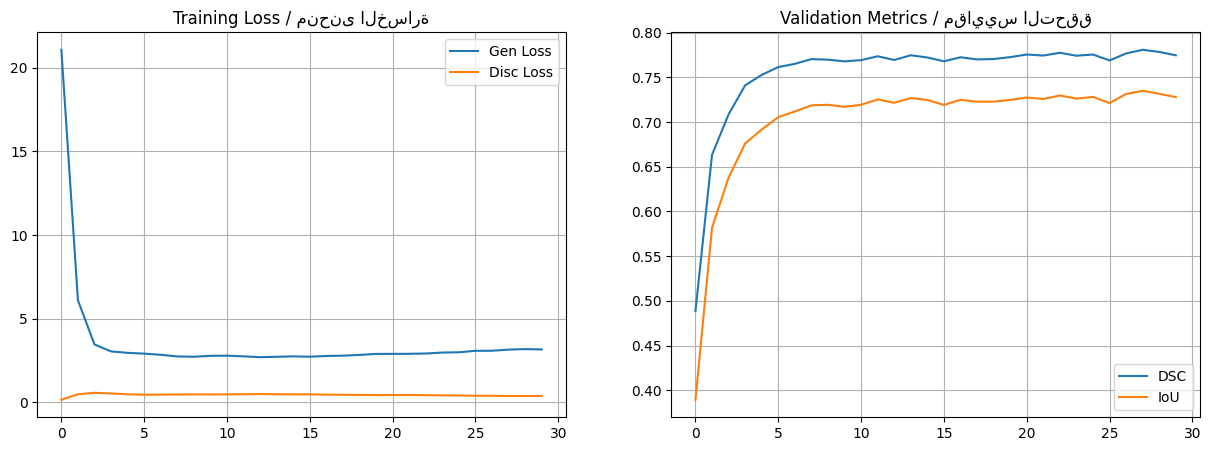

UnpicklingError: Weights only load failed. This file can still be loaded, to do so you have two options, [1mdo those steps only if you trust the source of the checkpoint[0m. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL numpy._core.multiarray.scalar was not an allowed global by default. Please use `torch.serialization.add_safe_globals([numpy._core.multiarray.scalar])` or the `torch.serialization.safe_globals([numpy._core.multiarray.scalar])` context manager to allowlist this global if you trust this class/function.

Check the documentation of torch.load to learn 

In [ ]:
# ============================================================
# BTS-GAN + PDC FULL PROFESSIONAL PIPELINE
# Google Colab Ready Version (Arabic / Turkish)
# ============================================================

import os
import gc
import json
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from google.colab import drive

warnings.filterwarnings("ignore")

# ============================================================
# 1. GOOGLE DRIVE BAĞLAMA / ربط غوغل درايف
# ============================================================
print("\n🔵 Google Drive bağlanıyor...")
print("🔵 يتم ربط Google Drive ...")
drive.mount('/content/drive')

# ============================================================
# 2. DOSYA YOLLARI / مسارات الملفات
# ============================================================
IMAGE_PATH = '/content/drive/MyDrive/Colab Notebooks/BTS DATASET/dataset/seg/train/images'
MASK_PATH  = '/content/drive/MyDrive/Colab Notebooks/BTS DATASET/dataset/seg/train/labels'
SAVE_DIR = '/content/drive/MyDrive/Colab Notebooks/BTS DATASET/BTS_GAN_OUTPUT'
os.makedirs(SAVE_DIR, exist_ok=True)

print("\n✅ Kayıt klasörü hazır / مجلد الحفظ جاهز")

# ============================================================
# 3. HYPERPARAMETERS / إعدادات التدريب
# ============================================================
IMG_SIZE = 256
BATCH_SIZE = 8
TOTAL_EPOCHS = 30 # تم الضبط على 30 بناءً على طلبك
LR_G = 1e-4
LR_D = 1e-4
BETA1 = 0.5
LAMBDA_L1 = 100.0  # لزيادة دقة التفاصيل المكانية
LAMBDA_DICE = 10.0 # للتركيز على استخراج الورم
THRESHOLD = 0.5
SEED = 42
NUM_WORKERS = 2
EARLY_STOPPING = True
PATIENCE = 15
SAVE_CHECKPOINT_EVERY = 5

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("\n================================================")
print("🚀 BTS-GAN + PDC BAŞLATILIYOR / بدء تشغيل النظام")
print("================================================")
print(f"📌 Device / الجهاز            : {device}")
print(f"📌 Image Size / حجم الصورة    : {IMG_SIZE}")
print(f"📌 Batch Size / حجم الدفعة    : {BATCH_SIZE}")
print(f"📌 Epoch / عدد الإيبوك        : {TOTAL_EPOCHS}")

# ============================================================
# 4. RANDOM SEED / تثبيت العشوائية
# ============================================================
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
seed_everything(SEED)

# ============================================================
# 5. DATA LOADING / تحميل البيانات
# ============================================================
def list_image_files(root_path):
    exts = (".png", ".jpg", ".jpeg", ".bmp", ".tif")
    all_files = []
    for root, dirs, files in os.walk(root_path):
        for file in files:
            if file.lower().endswith(exts):
                all_files.append(os.path.join(root, file))
    return sorted(all_files)

image_files = list_image_files(IMAGE_PATH)
mask_files  = list_image_files(MASK_PATH)

mask_map = {os.path.splitext(os.path.basename(m))[0]: m for m in mask_files}
pairs = []
for img in tqdm(image_files, desc="🔍 Eşleştirme / مطابقة البيانات"):
    stem = os.path.splitext(os.path.basename(img))[0]
    if stem in mask_map:
        pairs.append((img, mask_map[stem]))

print(f"\n✅ Eşleşen Veri / البيانات المطابقة: {len(pairs)}")

random.shuffle(pairs)
n_total = len(pairs)
n_train = int(0.70 * n_total)
n_val   = int(0.15 * n_total)
train_pairs = pairs[:n_train]
val_pairs   = pairs[n_train:n_train+n_val]
test_pairs  = pairs[n_train+n_val:]

# ============================================================
# 6. DATASET & DATALOADER / تجهيز الداتا
# ============================================================
class BTSDataset(Dataset):
    def __init__(self, pairs, img_size=256):
        self.pairs = pairs
        self.img_transform = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ColorJitter(brightness=0.1, contrast=0.1),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5])
        ])
        self.mask_transform = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor()
        ])
    def __len__(self): return len(self.pairs)
    def __getitem__(self, idx):
        img_path, mask_path = self.pairs[idx]
        img = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")
        return self.img_transform(img), (self.mask_transform(mask) > THRESHOLD).float()

train_loader = DataLoader(BTSDataset(train_pairs, IMG_SIZE), batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(BTSDataset(val_pairs, IMG_SIZE), batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(BTSDataset(test_pairs, IMG_SIZE), batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

# ============================================================
# 7. MODELS (PDC, GENERATOR, DISCRIMINATOR) / (PDCBlock: استخدام تمدد متوازي لالتقاط تفاصيل الورم) بناء المعمارية
# ============================================================
class PDCBlock(nn.Module):
  # PDC: Paralel Genişletilmiş Konvolüsyon. Tümör sınırlarını belirginleştirir.
    # PDC: تمدد متوازي للكونفولوشن. يبرز حدود الورم بدقة.
    def __init__(self, channels):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, 3, padding=1, dilation=1)
        self.conv2 = nn.Conv2d(channels, channels, 3, padding=2, dilation=2)
        self.conv3 = nn.Conv2d(channels, channels, 3, padding=3, dilation=3)
        self.bn = nn.BatchNorm2d(channels)
        self.relu = nn.ReLU(inplace=True)
    def forward(self, x):
        return self.relu(self.bn(self.conv1(x) + self.conv2(x) + self.conv3(x)))

class Generator(nn.Module):
  # Generator U-Net mimarisi ile maske üretir.
    # المولد يستخدم U-Net لإنتاج الماسك.
    def __init__(self):
        super().__init__()
        def down(in_c, out_c, norm=True):
            layers = [nn.Conv2d(in_c, out_c, 4, 2, 1)]
            if norm: layers.append(nn.BatchNorm2d(out_c))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            return nn.Sequential(*layers)

        def up(in_c, out_c):
            return nn.Sequential(
                nn.ConvTranspose2d(in_c, out_c, 4, 2, 1),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True)
            )

        self.d1 = down(3, 64, False)
        self.d2 = down(64, 128)
        self.d3 = down(128, 256)
        self.d4 = down(256, 512)
        self.pdc = PDCBlock(512)
        self.u1 = up(512, 256)
        self.u2 = up(512, 128)
        self.u3 = up(256, 64)
        self.u4 = up(128, 64)
        self.final = nn.Sequential(nn.Conv2d(64, 1, 1), nn.Sigmoid())

    def forward(self, x):
        d1, d2, d3, d4 = self.d1(x), self.d2(self.d1(x)), self.d3(self.d2(self.d1(x))), self.d4(self.d3(self.d2(self.d1(x))))
        pdc = self.pdc(d4)
        u1 = self.u1(pdc)
        u2 = self.u2(torch.cat([u1, d3], 1))
        u3 = self.u3(torch.cat([u2, d2], 1))
        return self.final(self.u4(torch.cat([u3, d1], 1)))

class Discriminator(nn.Module):
  # PatchGAN: Görüntünün yerel kısımlarını gerçeklik açısından denetler.
    # PatchGAN: يراقب أجزاء الصورة للتحقق من واقعيتها.
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(4, 64, 4, 2, 1), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 256, 4, 2, 1), nn.BatchNorm2d(256), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(256, 1, 4, 1, 1)
        )
    def forward(self, img, mask):
        return self.model(torch.cat([img, mask], 1))

G, D = Generator().to(device), Discriminator().to(device)

# ============================================================
# 8. LOSS & METRICS / دمج الخسائر (GAN + L1 + Dice) لتحقيق توازن بين الواقعية والدقة
# ============================================================
criterion_gan = nn.BCEWithLogitsLoss()
criterion_l1  = nn.L1Loss()
optimizer_G = optim.Adam(G.parameters(), lr=LR_G, betas=(BETA1, 0.999))
optimizer_D = optim.Adam(D.parameters(), lr=LR_D, betas=(BETA1, 0.999))
scaler = torch.cuda.amp.GradScaler()

def dice_loss(pred, target, smooth=1):
    pred, target = pred.view(-1), target.view(-1)
    return 1 - ((2. * (pred * target).sum() + smooth) / (pred.sum() + target.sum() + smooth))

def calculate_metrics(pred, target, eps=1e-6):
    pred = (pred > 0.5).float()
    tp = (pred * target).sum(dim=(1,2,3))
    fp = (pred * (1 - target)).sum(dim=(1,2,3))
    fn = ((1 - pred) * target).sum(dim=(1,2,3))
    tn = ((1 - pred) * (1 - target)).sum(dim=(1,2,3))

    dsc = (2 * tp + eps) / (2 * tp + fp + fn + eps)
    iou = (tp + eps) / (tp + fp + fn + eps)
    tpr = (tp + eps) / (tp + fn + eps) # Sensitivity (Recall)
    mcr = (fp + fn + eps) / (tp + tn + fp + fn + eps) # Misclassification Rate

    return dsc.mean().item(), iou.mean().item(), tpr.mean().item(), mcr.mean().item()

# ============================================================
# 9. TRAINING LOOP / حلقة التدريب
# ============================================================
history = {"train_G": [], "train_D": [], "val_DSC": [], "val_IOU": []}
best_dsc, early_counter = 0, 0
checkpoint_path = os.path.join(SAVE_DIR, "best_bts_gan.pth")

print("\n================================================")
print("🔥 Eğitim Başlıyor / بدء التدريب")
print("================================================")

for epoch in range(1, TOTAL_EPOCHS + 1):
    G.train(); D.train()
    g_losses, d_losses = [], []

    loop = tqdm(train_loader, leave=False)
    for img, mask in loop:
        img, mask = img.to(device), mask.to(device)

        # Train Generator
        optimizer_G.zero_grad()
        with torch.cuda.amp.autocast():
            fake_mask = G(img)
            pred_fake = D(img, fake_mask)
            loss_g = criterion_gan(pred_fake, torch.ones_like(pred_fake)) + \
                     LAMBDA_L1 * criterion_l1(fake_mask, mask) + LAMBDA_DICE * dice_loss(fake_mask, mask)
        scaler.scale(loss_g).backward()
        scaler.step(optimizer_G)

        # Train Discriminator
        optimizer_D.zero_grad()
        with torch.cuda.amp.autocast():
            loss_d = (criterion_gan(D(img, mask), torch.ones_like(pred_fake)) +
                      criterion_gan(D(img, fake_mask.detach()), torch.zeros_like(pred_fake))) * 0.5
        scaler.scale(loss_d).backward()
        scaler.step(optimizer_D)
        scaler.update()

        g_losses.append(loss_g.item()); d_losses.append(loss_d.item())
        loop.set_description(f"Epoch {epoch} | G: {loss_g.item():.3f} D: {loss_d.item():.3f}")

    # Validation
    G.eval()
    val_dsc, val_iou = [], []
    with torch.no_grad():
        for img, mask in val_loader:
            dsc, iou, _, _ = calculate_metrics(G(img.to(device)), mask.to(device))
            val_dsc.append(dsc); val_iou.append(iou)

    avg_g, avg_d = np.mean(g_losses), np.mean(d_losses)
    avg_dsc, avg_iou = np.mean(val_dsc), np.mean(val_iou)
    history["train_G"].append(avg_g); history["train_D"].append(avg_d)
    history["val_DSC"].append(avg_dsc); history["val_IOU"].append(avg_iou)

    print(f"📌 Epoch {epoch}/{TOTAL_EPOCHS} | L_G: {avg_g:.4f} | L_D: {avg_d:.4f} | DSC: {avg_dsc:.4f} | IOU: {avg_iou:.4f}")

    if avg_dsc > best_dsc:
        best_dsc = avg_dsc
        early_counter = 0
        torch.save({"G_state_dict": G.state_dict(), "D_state_dict": D.state_dict(), "best_dsc": best_dsc}, checkpoint_path)
        print("✅ Yeni en iyi model kaydedildi / تم حفظ أفضل موديل")
    else:
        early_counter += 1
        if early_counter >= PATIENCE:
            print("🛑 Early Stopping Aktif / تم تفعيل الإيقاف المبكر"); break

# ============================================================
# 10. VISUALIZATION & PLOTS / الرسوم البيانية والصور
# ============================================================
print("\n📊 Grafikler oluşturuluyor... / جاري إنشاء الرسوم البيانية...")
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.plot(history["train_G"], label="Gen Loss"); plt.plot(history["train_D"], label="Disc Loss")
plt.title("Training Loss / منحنى الخسارة"); plt.legend(); plt.grid()
plt.subplot(1, 2, 2)
plt.plot(history["val_DSC"], label="DSC"); plt.plot(history["val_IOU"], label="IoU")
plt.title("Validation Metrics / مقاييس التحقق"); plt.legend(); plt.grid()
plt.savefig(os.path.join(SAVE_DIR, "training_curves.png"))
plt.show()

# Show Predictions
G.load_state_dict(torch.load(checkpoint_path, map_location=device)["G_state_dict"])
G.eval()
print("\n👁️ Tahminler görselleştiriliyor... / جاري عرض نتائج التنبؤ (قبل وبعد)...")
with torch.no_grad():
    img, mask = next(iter(test_loader))
    pred = (G(img.to(device)).cpu() > 0.5).float()

    plt.figure(figsize=(12, 8))
    for i in range(3): # Show 3 examples
        plt.subplot(3, 4, i*4 + 1); plt.imshow((img[i].permute(1,2,0).numpy()+1)/2); plt.title("Input"); plt.axis('off')
        plt.subplot(3, 4, i*4 + 2); plt.imshow(mask[i].squeeze(), cmap='gray'); plt.title("True Mask"); plt.axis('off')
        plt.subplot(3, 4, i*4 + 3); plt.imshow(pred[i].squeeze(), cmap='gray'); plt.title("Predicted"); plt.axis('off')
        plt.subplot(3, 4, i*4 + 4); plt.imshow((img[i].permute(1,2,0).numpy()+1)/2)
        plt.imshow(pred[i].squeeze(), cmap='jet', alpha=0.4); plt.title("Overlay"); plt.axis('off')
    plt.savefig(os.path.join(SAVE_DIR, "predictions.png"))
    plt.show()

# ============================================================
# 11. FINAL TEST EVALUATION (DSC, IOU, TPR, MCR) / التقييم النهائي
# ============================================================
test_metrics = []
with torch.no_grad():
    for img, mask in test_loader:
        d, i, t, m = calculate_metrics(G(img.to(device)), mask.to(device))
        test_metrics.append({"DSC": d, "IoU": i, "TPR": t, "MCR": m})

df_test = pd.DataFrame(test_metrics)
df_test.to_csv(os.path.join(SAVE_DIR, "final_test_metrics.csv"), index=False)
print("\n================================================")
print("📈 TEST SONUÇLARI / نتائج الاختبار النهائي")
print("================================================")
print(df_test.mean())
print("\n🎉 Eğitim Başarıyla Tamamlandı / اكتمل التدريب بنجاح!")